# Figure 2: Dataset Overview

---
## Imports

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from matplotlib.ticker import FuncFormatter, FixedLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
import matplotlib as mpl

import warnings

warnings.filterwarnings(
    "ignore",
    message="When grouping with a length-1 list-like, you will need to pass a length-1 tuple",
    category=FutureWarning,
    module="seaborn._base"
)

In [2]:
import os
import sys
sys.path.append(os.path.abspath('/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/all-GCL-manuscript/'))
from all_gcl_manuscript import style

---
## helper function

In [3]:
def add_additional_info(df):
    label_encoder = LabelEncoder()
    encoded_experimenter = label_encoder.fit_transform(df['experimenter'].values)
    label_encoder = LabelEncoder()
    encoded_gender = label_encoder.fit_transform(df['animgender'].values)

    df['experimenter_id']=encoded_experimenter+1
    df['age_weeks'] = df['age']/7
    df['experimenter_id'] = df['experimenter_id'].replace({1: '1',2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7'})
    df['gender_label'] = df['animgender'].map({'male': 0, 'female': 1})    
    df = df.reset_index()

    return df

In [4]:
gcl_group_names = ['Off local, OS', 
                   'Off DS', 
                   'Off step', 
                   'Off slow', 
                   'Off alpha sust.',
                   '(On-)Off "JAM-B"', 
                   'Off sust.', 
                   'Off alpha trans.',
                   'Off "mini" alpha trans.', 
                   'On-Off local-edge "W3"', 
                   'On-Off local',
                   'On-Off DS 1',
                   'On-Off DS 2', 
                   '(On-)Off local, OS', 
                   'On step', 
                   'On DS trans.', 
                   'On local trans., OS', 
                   'On transient', 
                   'On transient large', 
                   'On high freq.', 
                   'On low freq.', 
                   'On sust.', 
                   'On "mini" alpha', 
                   'On alpha', 
                   'On DS sust. 1', 
                   'On DS sust. 2', 
                   'On slow', 
                   'On contrast supp.', 
                   'On DS sust. 3', 
                   'On local sust., OS', 
                   'Off supp. 1', 
                   'Off supp. 2', 
                   'Off', 
                   'On high freq. sust. 1', 
                   'On high freq. trans.', 
                   'On-Off high freq.', 
                   'On high freq. sust. 2', 
                   'On sust. 1', 
                   'On sust. 2', 
                   'On sust. 3', 
                   'On sust. 4', 
                   'On SAC', 
                   'On-Off local', 
                   'On step', 
                   'On local 1', 
                   'On local 2']

---
## Load and quality filter dataset

In [66]:
from all_gcl_manuscript.utils import restore_numpy_arrays

dataset_path = "/gpfs01/euler/data/Resources/All-GCL/database/"
all_gcl_df = pd.read_parquet(os.path.join(dataset_path, "all_GCL_table.parquet"))
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


In [68]:
from all_gcl_manuscript.dataframe import filter_df

# non-filtered, all cells
all_gcl_df_nf = filter_df(
    df=all_gcl_df,
    condition_filter=False,
    quality_filter=False,
    location_filter=False,
    genline_filter=True,
    rf_quality_filter=False,
    verbose=True)
all_gcl_df_nf = all_gcl_df_nf[all_gcl_df_nf['animgender'].isin(['male', 'female'])]

# non-filtered, location
all_gcl_df_nf_loc = filter_df(
    df=all_gcl_df,
    condition_filter=False,
    quality_filter=False,
    location_filter=True,
    genline_filter=False,
    rf_quality_filter=False,
    verbose=True)

# quality filtered
all_gcl_df_filt = filter_df(
    df=all_gcl_df,
    condition_filter=False,
    quality_filter=True,
    location_filter=False,
    genline_filter=False,
    rf_quality_filter=False,
    verbose=True)

# quality filtered + location
all_gcl_df_filt_loc = filter_df(
    df=all_gcl_df,
    condition_filter=False,
    quality_filter=True,
    location_filter=True,
    genline_filter=False,
    rf_quality_filter=False,
    verbose=True)

# RFs
all_gcl_df_rfs = filter_df(
    df=all_gcl_df,
    condition_filter=False,
    quality_filter=True,
    location_filter=False,
    genline_filter=False,
    rf_quality_filter=True,
    verbose=True)

Filtering genline. Removing 0% of the data.
Filtering location. Removing 14% of the data.
Filtering quality. Removing 38% of the data.
Filtering quality. Removing 38% of the data.
Filtering location. Removing 8% of the data.
Filtering quality. Removing 38% of the data.
Filtering RF. Removing 57% of the data.


---
## Overview

In [69]:
n_rois = all_gcl_df_nf.shape[0]
n_rois_loc = all_gcl_df_nf_loc.shape[0]
n_filt_rois = all_gcl_df_filt.shape[0]
n_filt_rois_loc = all_gcl_df_filt_loc.shape[0]
n_filt_rois_group = (all_gcl_df_filt[all_gcl_df_filt.prob_group>0.3]).shape[0]
n_filt_rois_group_loc = (all_gcl_df_filt_loc[all_gcl_df_filt_loc.prob_group>0.3]).shape[0]
n_filt_rois_rf = all_gcl_df_rfs.shape[0]

print(
    f"# ROIs: {n_rois}\n"
    f"# ROIs + Location: {n_rois_loc}\n"
    f"# quality filtered ROIs: {n_filt_rois}\n"
    f"# quality filtered ROIs with loc: {n_filt_rois_loc}\n"
    f"# quality filtered ROIs classified >0.5: {n_filt_rois_group}\n"
    f"# quality filtered ROIs classified >0.5 # location: {n_filt_rois_group_loc}\n"
    f"# quality filtered ROIs with RF: {n_filt_rois_rf}\n"
)

print(f"-----------------------------------------------------------")

df_eyes = all_gcl_df_nf[['experimenter','date','exp_num','eye']].drop_duplicates()

print(
    f"# ROIs (Male): {all_gcl_df_nf[all_gcl_df_nf['animgender'] == 'male'].shape[0]}\n"
    f"# ROIs (Female): {all_gcl_df_nf[all_gcl_df_nf['animgender'] == 'female'].shape[0]}\n"
    f"# Scan Fields: {all_gcl_df_nf[['experimenter','date','exp_num','field']].drop_duplicates().shape[0]}\n"
    f"# Eyes: {all_gcl_df_nf[['experimenter','date','exp_num','eye']].drop_duplicates().shape[0]}\n"
    f"# Eyes (Left): {df_eyes[df_eyes['eye']=='left'].shape[0]}\n"
    f"# Eyes (Right): {df_eyes[df_eyes['eye']=='right'].shape[0]}\n"
)

# ROIs: 84451
# ROIs + Location: 72475
# quality filtered ROIs: 52189
# quality filtered ROIs with loc: 45672
# quality filtered ROIs classified >0.5: 47540
# quality filtered ROIs classified >0.5 # location: 41641
# quality filtered ROIs with RF: 3613

-----------------------------------------------------------
# ROIs (Male): 40684
# ROIs (Female): 43767
# Scan Fields: 672
# Eyes: 203
# Eyes (Left): 103
# Eyes (Right): 100



---
## Plotting

In [76]:
label_encoder = LabelEncoder()
encoded_experimenter = label_encoder.fit_transform(all_gcl_df_nf['experimenter'].values)

label_encoder = LabelEncoder()
encoded_gender = label_encoder.fit_transform(all_gcl_df_nf['animgender'].values)

all_gcl_df_nf['experimenter_id']=encoded_experimenter+1
all_gcl_df_nf['age'] = all_gcl_df_nf['age'].astype(int)
all_gcl_df_nf['age_weeks'] = all_gcl_df_nf['age'] / 7

/tmp/ipykernel_6732/3300178146.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


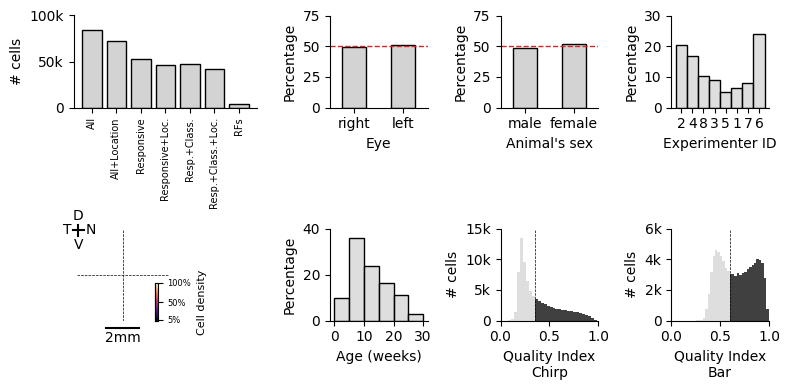

In [79]:
save = 0
plot_heatmaps = 0 # retinal location heatmap; can be disabled as plotting may take a while
fontsize_labels = 10

fig, ax = plt.subplot_mosaic("""
AAABBCCDD
EE.FFGGHH
""",  figsize=(8,4))


###########################################
#####  number of cells
###########################################

labels = ['All', 'All+Location','Responsive','Responsive+Loc.','Resp.+Class.','Resp.+Class.+Loc.','RFs']
counts = [n_rois, n_rois_loc, n_filt_rois, n_filt_rois_loc,n_filt_rois_group,n_filt_rois_group_loc,n_filt_rois_rf]
ax['A'].bar(np.arange(0,7,1),
          counts,
          color='lightgray',
          edgecolor='k')
ax['A'].set_ylabel('# cells',fontsize=fontsize_labels)
ax['A'].set_xticks(np.arange(0, 7))
ax['A'].set_xticklabels(labels,rotation=90,fontsize=7)
ax['A'].set_ylim(0,100000)
ax['A'].yaxis.set_major_locator(FixedLocator([0, 50_000, 100_000]))
ax['A'].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{int(y/1000):d}k' if y else '0'))



###########################################
#####  Number of eyes
###########################################

sns.countplot(
    data=all_gcl_df_nf,
    x='eye',
    color='lightgray',
    stat='percent',   
    ax=ax['B'],
    edgecolor='k',
    width=0.5
)
ax['B'].set_xlabel(' ')
ax['B'].axhline(50,color='tab:red',lw=1,ls='--')
ax['B'].set_ylim(0,75)
ax['B'].set_xlabel('Eye',fontsize=fontsize_labels)
ax['B'].set_ylabel('Percentage',fontsize=fontsize_labels)
ax['B'].set_yticks([0, 25, 50, 75])
ax['B'].set_yticklabels(['0', '25', '50', '75'])



###########################################
#####  SEX
###########################################

sns.countplot(
    data=all_gcl_df_nf,
    x='animgender',
    color='lightgray',
    stat='percent',   
    ax=ax['C'],
    edgecolor='k',
    width=0.5)
ax['C'].set_xlabel("Animal's sex",fontsize=fontsize_labels)
ax['C'].axhline(50,color='tab:red',lw=1,ls='--')
ax['C'].set_ylim(0,75)
ax['C'].set_ylabel(' ')
ax['C'].set_ylabel('Percentage',fontsize=fontsize_labels)
ax['C'].set_yticks([0, 25, 50, 75])
ax['C'].set_yticklabels(['0', '25', '50', '75'])

###########################################
#####  Experimenter
###########################################

all_gcl_df_nf['experimenter_id'] = all_gcl_df_nf['experimenter_id'].astype('int').astype('string')
sns.histplot(data=all_gcl_df_nf, 
             x='experimenter_id',
             color='lightgray',
             stat='percent',
             ax=ax['D'])
ax['D'].set_xlabel('Experimenter ID',fontsize=fontsize_labels)
ax['D'].set_ylim(0,30)
ax['D'].set_ylabel(' ')
ax['D'].set_ylabel('Percentage',fontsize=fontsize_labels)
ax['D'].set_yticks([0, 10, 20, 30])
ax['D'].set_yticklabels(['0', '10', '20', '30'])

###########################################
#####  Location
###########################################

if plot_heatmaps == 1:
    sns.kdeplot(
        data=all_gcl_df_nf,
        x='temporal_nasal_pos_um', y='ventral_dorsal_pos_um',
        fill=True, cmap='magma', bw_adjust=0.5,
        ax=ax['E'], cbar=False)
vmaxs = []
for coll in ax['E'].collections:
    if hasattr(coll, "get_clim"):
        vmin_c, vmax_c = coll.get_clim()
        vmaxs.append(vmax_c)
vmax = max(vmaxs) if vmaxs else 1.0
vmin = 0.0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.5 * vmax, vmax=vmax)
for coll in ax['E'].collections:
    if hasattr(coll, "set_norm"):
        coll.set_norm(norm)
height_pct = 0.42
y0 = 0.2 - height_pct/2
cax = inset_axes(ax['E'], width="3%", height=f"{height_pct*100:.0f}%",loc='lower left', bbox_to_anchor=(0.85, y0, 1, 1), bbox_transform=ax['E'].transAxes, borderpad=0.0)
cmap = mpl.colormaps['magma']  
sm = ScalarMappable(norm=norm, cmap=cmap)
cb = ax['E'].figure.colorbar(sm, cax=cax, orientation='vertical')
cb.set_label('Cell density', fontsize=8)
cb.ax.tick_params(labelsize=6)
ticks = np.array([0.05, 0.50, 1.00]) * vmax
cb.set_ticks(ticks)
cb.set_ticklabels([f"{p:.0f}%" for p in [5, 50, 100]])
ax['E'].set_xlim(-2750,2750)
ax['E'].set_ylim(-2750,2750)
ax['E'].axhline(0,ls='--',color='k',lw=0.5)
ax['E'].axvline(0,ls='--',color='k',lw=0.5)
ax['E'].set_xlabel('Temporal <-> Nasal')
ax['E'].set_ylabel('Ventral <-> Dorsal')
ax['E'].set_aspect('equal')
ax['E'].axis('off')
td = 0.02          # text offset in axes fraction
x0, y0, s = 0.02, 0.98, 0.06   # center & half-size of the cross
tr = ax["E"].transAxes
ax["E"].plot([x0 - s, x0 + s], [y0, y0], c='k', transform=tr, clip_on=False)
ax["E"].plot([x0, x0], [y0 - s, y0 + s], c='k', transform=tr, clip_on=False)
ax["E"].text(x0 - s - td, y0, 'T', ha='right', va='center', transform=tr)
ax["E"].text(x0 + s + td, y0, 'N', ha='left',  va='center', transform=tr)
ax["E"].text(x0, y0 - s - td, 'V', ha='center', va='top',    transform=tr)
ax["E"].text(x0, y0 + s + td, 'D', ha='center', va='bottom', transform=tr)
r_max=-3200
ax["E"].plot([-1000, 1000], [r_max, r_max], c='k', dash_capstyle='butt', clip_on=False)
ax["E"].text(0, r_max-200, '2mm', c='k', va='top', ha='center')


###########################################
#####  AGE
###########################################
bin_edges = np.arange(0, 35, 5)

sns.histplot(data=all_gcl_df_nf, 
             x='age_weeks',
             shrink=1,
             color='lightgray',
             stat='percent',
             bins=bin_edges,
             ax=ax['F'])
ax['F'].set_xlabel('Age (weeks)',fontsize=fontsize_labels)
ax['F'].set_ylim(0,40)
ax['F'].set_ylabel('Percentage',fontsize=fontsize_labels)
ax['F'].set_yticks([0, 20, 40])
ax['F'].set_yticklabels(['0', '20', '40'])
ax['F'].set_xticks([0, 10, 20, 30])

###########################################
#####  QUALITY INDEX
###########################################
qi_chirp = all_gcl_df_nf['chirp_qidx']
qi_bar   = all_gcl_df_nf['bar_qidx']

bins = 31
n, bins_chirp, patches = ax['G'].hist(qi_chirp, bins=bins, alpha=0.75, color='k', label='QI$_{\\mathrm{chirp}}$')
for p in patches:
    if p.get_x() + p.get_width() <= 0.35:  
        p.set_facecolor('lightgray')
ax['G'].set_xlim(0, 1)
ax['G'].set_xlabel('Quality Index\nChirp', fontsize=fontsize_labels)
ax['G'].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax['G'].set_ylim(0, 15000)
ax['G'].set_yticks([0, 5000, 10000, 15000])
ax['G'].set_yticklabels(['0', '5k', '10k', '15k'])
ax['G'].axvline(0.35, ls='--', lw=0.5, color='k')
ax['G'].set_ylabel('# cells', fontsize=fontsize_labels)

bins = 30
n, bins_bar, patches = ax['H'].hist(qi_bar, bins=bins, alpha=0.75, color='k', label='QI$_{\\mathrm{bar}}$')
for p in patches:
    if p.get_x() + p.get_width() <= 0.6:
        p.set_facecolor('lightgray')
ax['H'].set_xlabel('Quality Index\nBar', fontsize=fontsize_labels)
ax['H'].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax['H'].set_xlim(0, 1)
ax['H'].set_ylim(0, 6000)
ax['H'].set_yticks([0, 2000, 4000, 6000])#, 6000])
ax['H'].set_yticklabels(['0', '2k', '4k', '6k'])#, '6k'])
ax['H'].axvline(0.6, ls='--', lw=0.5, color='k')
ax['H'].set_ylabel('# cells', fontsize=fontsize_labels)


fig.subplots_adjust(wspace=0.2, hspace=-0.1) 
sns.despine()
fig.tight_layout()


if save==1:
    figname = 'INSERT_FIGURE_NAME_'
    fig.patch.set_facecolor('white')
    fig.savefig("YOUR_PATH/{}.png".format(figname), dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("YOUR_PATH/{}.svg".format(figname), dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor(), transparent=False)